# Digital Advertising Campaign Performance Analysis

## **Phase 1 - Data Understanding**

In [2]:
import pandas as pd
import numpy as np 

In [3]:
campaign = pd.read_csv('/Users/audrey/Documents/Perso/Data Analyst_ Formation/Portfolio/Python/campaign_dataset_V1.csv')

### <span style="color:blue"> 1.1 Découverte du dataset </span>

In [76]:
campaign.head(2)

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier
0,CAMP_00001,Lead Generation,Facebook,Search,Mobile,Android,Text,728x90,Short,False,...,NaN,402.0,2,896.46,289.67,67.75,70.0,2.00,E-commerce,High
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,50094.0,467.0,5,1158.16,1728.20,63.73,105.0,2.74,Finance,Medium


In [77]:
#Taille du dataset 
campaign.shape

(10000, 31)

In [78]:
#Noms des colonnes
campaign.columns

Index(['campaign_id', 'campaign_objective', 'platform', 'ad_placement',
       'device_type', 'operating_system', 'creative_format', 'creative_size',
       'ad_copy_length', 'has_call_to_action', 'creative_emotion',
       'creative_age_days', 'target_audience_age', 'target_audience_gender',
       'audience_interest_category', 'income_bracket', 'purchase_intent_score',
       'retargeting_flag', 'start_date', 'quality_score', 'actual_cpc',
       'impressions', 'clicks', 'conversions', 'ad_spend', 'revenue',
       'bounce_rate', 'avg_session_duration_seconds', 'pages_per_session',
       'industry_vertical', 'budget_tier'],
      dtype='object')

In [79]:
# Le type des colonnes 
campaign.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   campaign_id                   10000 non-null  object 
 1   campaign_objective            10000 non-null  object 
 2   platform                      10000 non-null  object 
 3   ad_placement                  10000 non-null  object 
 4   device_type                   10000 non-null  object 
 5   operating_system              10000 non-null  object 
 6   creative_format               10000 non-null  object 
 7   creative_size                 10000 non-null  object 
 8   ad_copy_length                10000 non-null  object 
 9   has_call_to_action            10000 non-null  bool   
 10  creative_emotion              10000 non-null  object 
 11  creative_age_days             10000 non-null  int64  
 12  target_audience_age           10000 non-null  object 
 13  ta

In [80]:
# valeurs manquantes 

campaign.isna().sum()

campaign_id                     0
campaign_objective              0
platform                        0
ad_placement                    0
device_type                     0
operating_system                0
creative_format                 0
creative_size                   0
ad_copy_length                  0
has_call_to_action              0
creative_emotion                0
creative_age_days               0
target_audience_age             0
target_audience_gender          0
audience_interest_category      0
income_bracket                  0
purchase_intent_score           0
retargeting_flag                0
start_date                      0
quality_score                   0
actual_cpc                      0
impressions                     4
clicks                          2
conversions                     0
ad_spend                        0
revenue                         0
bounce_rate                     0
avg_session_duration_seconds    1
pages_per_session               0
industry_verti

In [81]:
# Doublons
campaign.duplicated().sum()

np.int64(0)

**Premières observations :**
- Le type de la colonne start date est à modifier
- Peu de valeurs manquantes : 4 au niveau des impressions, 2 au niveau des clics et 1 pour le temps de session
- Pas de doublon 
- La définition de certaines variables devra être vérifiée avec le métier ou la documentation: ad_copy_length , income_bracket, le quality score, actual cpc (vs cpc)

### <span style="color:blue"> 1.2 Contexte et objectif du projet </span>

**Analyses envisagées :**

La notion de performance dépend de l’objectif de la campagne. 
Les analyses seront donc réalisées avec les KPI les plus pertinents pour chaque objectif.  
Les analyses porteront notamment sur les questions suivantes :

* Quelles plateformes publicitaires obtiennent les meilleures performances selon l’objectif de campagne ?
* Le type de creatives influence-t-il les performances ?
* Certains emplacements publicitaires (ad placement) sont-ils plus performants que d’autres ?
* Le device a-t-il un impact sur les résultats des campagnes ?
* La présence d’un call-to-action (CTA) améliore-t-elle les performances ?
* La mise en place du retargeting agie t-elle sur les performances ?
* Quels segments d’audience (âge, genre) génèrent le plus de clics ou de conversions ?
* Le budget a t-il un impact sur les performances ? 


### <span style="color:blue"> 1.3 Compréhension des variables du dataset </span>

* ad_copy_length: Longueur du texte sur les ads 	
* income_bracket: Revenu du foyer 
* quality score: note qualité de la plateforme 
* actual cpc : eCPC (campagne en cours)

Les autres données ne posent pas de problème de compréhension

### <span style="color:blue"> 1.4 Evaluation de la qualité des données  </span>

In [82]:
# Rappel des valeurs manquantes

campaign.isna().sum()

campaign_id                     0
campaign_objective              0
platform                        0
ad_placement                    0
device_type                     0
operating_system                0
creative_format                 0
creative_size                   0
ad_copy_length                  0
has_call_to_action              0
creative_emotion                0
creative_age_days               0
target_audience_age             0
target_audience_gender          0
audience_interest_category      0
income_bracket                  0
purchase_intent_score           0
retargeting_flag                0
start_date                      0
quality_score                   0
actual_cpc                      0
impressions                     4
clicks                          2
conversions                     0
ad_spend                        0
revenue                         0
bounce_rate                     0
avg_session_duration_seconds    1
pages_per_session               0
industry_verti

In [83]:
# Part des valeurs manquantes dans la colonne 'impressions' 

(campaign['impressions'].isna().sum()/len(campaign))*100

np.float64(0.04)

In [84]:
# Part des valeurs manquantes dans la colonne 'clicks' 

(campaign['clicks'].isna().sum()/len(campaign))*100

np.float64(0.02)

In [85]:
# Part des valeurs manquantes dans la colonne 'avg_session_duration_seconds' 
(campaign['avg_session_duration_seconds'].isna().sum()/len(campaign))*100

np.float64(0.01)

In [86]:
# visualisation des valeurs 'date' 

campaign['start_date']

0       2024-03-06
1       2024-01-26
2       2025-05-15
3       2024-07-21
4       2025/03/09
           ...    
9995    2026-01-18
9996    2025-01-22
9997    2024-10-01
9998    2025-12-28
9999    2024-08-17
Name: start_date, Length: 10000, dtype: object

In [87]:
# Analyse textuelle de la colonne 'platform'

campaign['platform'].value_counts()

platform
Google Ads    2933
Facebook      2527
LinkedIn      1468
TikTok        1213
Twitter       1029
Instagram      830
Name: count, dtype: int64

In [88]:
# Analyse textuelle de la colonne 'device'

campaign['device_type'].value_counts()

device_type
Mobile     5430
Desktop    3556
Tablet     1014
Name: count, dtype: int64

In [89]:
# Analyse textuelle de la colonne 'campaign objective'

campaign['campaign_objective'].value_counts()

campaign_objective
Lead Generation    3563
Conversions        2946
Brand Awareness    2043
App Installs        746
Engagement          702
Name: count, dtype: int64

In [90]:
# Analyse de la cohérence de la colonne 'impressions'

campaign[campaign['impressions']<0]

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier


In [91]:
# Analyse la cohérence des colonnes 'impressions' et 'clicks'

campaign[campaign['impressions']< campaign['clicks']]

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier


In [92]:
# Analyse la cohérence des colonnes 'conversions' et 'clicks'

campaign[campaign['clicks']< campaign['conversions']]

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier


In [93]:
# Analyse la cohérence de la colonne 'ad_spend' 

campaign[campaign['ad_spend']< 0]

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier


In [94]:
# Analyse la cohérence de la colonne 'revenue' 

campaign[campaign['revenue']< 0]

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,industry_vertical,budget_tier


### Synthèse - Evaluation de la qualité des données
* Les valeurs manquantes représentent une part très faible du dataset (au maximum 0,04 % des observations selon les colonnes concernées). Leur impact sur les analyses devrait être limité.
* La colonne start_date présente plusieurs formats de dates. Une harmonisation sera nécessaire avant toute analyse temporelle. 
* Les variables catégorielles ne présentent pas d’incohérences apparentes (casse, espaces ou doublons de catégories)
* Les contrôles de cohérence réalisés sur les variables numériques (impressions, clics, conversions, dépenses et revenus) n’ont révélé aucune anomalie majeure.

## Phase 2 - Data Cleaning

### <span style="color:blue"> 2.1 Quelles sont les colonnes à 'nettoyer' ? </span>

* Formater la colonne date
* Gérer les valeurs manquantes 
* Vérifier si d'autre colonnes nécessite un nettoyage 

### <span style="color:blue"> 2.2 La colonne date </span>

In [95]:
campaign['start_date'] = pd.to_datetime(campaign['start_date'], format='mixed')

In [96]:
#vérification du format
campaign['start_date'].dtype

dtype('<M8[ns]')

### <span style="color:blue"> 2.3 Les valeurs manquantes </span>

Les variables **impressions** et **clicks** sont indispensables au calcul de plusieurs indicateurs clés (CTR, CPC, CPM, taux de conversion, etc.). Les lignes présentant des valeurs manquantes sur ces variables seront donc supprimées afin de garantir la fiabilité des analyses.

Une seule valeur est manquante pour **avg_session_duration_seconds**. Cette variable n’étant pas utilisée dans les analyses principales, aucune imputation n’est réalisée à ce stade.


In [97]:
# Supprimer les lignes où la metric impressions est manquante

campaign = campaign.dropna(subset=['impressions'])

# Supprimer les lignes où la metric click est manquante

campaign = campaign.dropna(subset=['clicks'])


### <span style="color:blue"> 2.4 Vérification après cleaning du dataset </span>

In [98]:
campaign.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9994 entries, 1 to 9999
Data columns (total 31 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   campaign_id                   9994 non-null   object        
 1   campaign_objective            9994 non-null   object        
 2   platform                      9994 non-null   object        
 3   ad_placement                  9994 non-null   object        
 4   device_type                   9994 non-null   object        
 5   operating_system              9994 non-null   object        
 6   creative_format               9994 non-null   object        
 7   creative_size                 9994 non-null   object        
 8   ad_copy_length                9994 non-null   object        
 9   has_call_to_action            9994 non-null   bool          
 10  creative_emotion              9994 non-null   object        
 11  creative_age_days             9994 

In [99]:
campaign.isna().sum()

campaign_id                     0
campaign_objective              0
platform                        0
ad_placement                    0
device_type                     0
operating_system                0
creative_format                 0
creative_size                   0
ad_copy_length                  0
has_call_to_action              0
creative_emotion                0
creative_age_days               0
target_audience_age             0
target_audience_gender          0
audience_interest_category      0
income_bracket                  0
purchase_intent_score           0
retargeting_flag                0
start_date                      0
quality_score                   0
actual_cpc                      0
impressions                     0
clicks                          0
conversions                     0
ad_spend                        0
revenue                         0
bounce_rate                     0
avg_session_duration_seconds    1
pages_per_session               0
industry_verti

À l’issue de cette phase de nettoyage, le dataset est prêt pour les étapes de data modeling et d’analyse. Les variables sont au bon format et les valeurs manquantes ont été traitées.

## Phase 3 - Data Modeling

Creation des KPIs qui permettront d'analyser les performances des campagnes 

### <span style="color:blue"> 3.1 Déterminer les valeurs à calculer  </span>

Pour analyser les performances des campagnes en fonction de leurs objectifs, les KPIs suivants doivent être calculés:
- CTR
- CPC
- CPM
- Conversion Rate
- CPA
- ROAS
- Profit

### <span style="color:blue"> 3.2 Creation des colonnes correspondantes </span>

In [100]:
campaign['CTR'] = campaign['clicks']/campaign['impressions']
campaign['CPC'] = campaign['ad_spend']/campaign['clicks']
campaign['CPM'] = (campaign['ad_spend']/campaign['impressions'])*1000
campaign['Conversion Rate'] = campaign['conversions']/campaign['clicks']
campaign['CPA'] = campaign['ad_spend']/campaign['conversions']
campaign['ROAS'] = campaign['revenue']/campaign['ad_spend']
campaign['Profit'] = campaign['revenue']- campaign['ad_spend']

In [101]:
campaign.head(2)

,campaign_id,campaign_objective,platform,ad_placement,device_type,operating_system,creative_format,creative_size,ad_copy_length,has_call_to_action,...,pages_per_session,industry_vertical,budget_tier,CTR,CPC,CPM,Conversion Rate,CPA,ROAS,Profit
1,CAMP_00002,Engagement,Facebook,Feed,Mobile,iOS,Image,320x50,Long,True,...,2.74,Finance,Medium,0.009322,2.48,23.119735,0.010707,231.632000,1.492195,570.04
2,CAMP_00003,Conversions,Google Ads,Feed,Tablet,iOS,Video,1920x1080,Short,False,...,3.97,Healthcare,Low,0.010330,3.88,40.081166,0.053571,72.426667,6.680919,2468.70


### <span style="color:blue"> 3.3 Vérification des KPIs </span>

In [102]:
campaign[
    [
        "CTR",
        "CPC",
        "CPM",
        "Conversion Rate",
        "CPA",
        "ROAS",
        "Profit"
    ]
].describe()

campaign.describe().round(2)

,creative_age_days,start_date,quality_score,actual_cpc,impressions,clicks,conversions,ad_spend,revenue,bounce_rate,avg_session_duration_seconds,pages_per_session,CTR,CPC,CPM,Conversion Rate,CPA,ROAS,Profit
count,9994.00,9994,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9993.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00,9994.00
mean,45.38,2025-01-13 01:32:47.500500480,5.53,3.29,70545.46,1526.52,65.57,4344.56,28406.51,52.53,100.94,3.11,0.02,3.29,70.97,0.04,inf,7.52,24061.95
min,1.00,2024-01-01 00:00:00,1.00,0.30,5000.00,10.00,0.00,8.69,0.00,10.00,10.00,1.00,0.00,0.30,1.35,0.00,1.72,0.00,-36939.84
25%,22.00,2024-07-06 00:00:00,4.00,1.51,16952.50,290.00,5.00,665.87,1608.05,40.09,68.00,2.16,0.01,1.51,24.77,0.01,51.86,1.20,210.36
50%,45.00,2025-01-13 00:00:00,6.00,2.43,37451.50,718.00,16.00,1895.43,6099.24,53.58,100.00,2.83,0.02,2.43,48.25,0.02,120.20,3.15,3302.54
75%,68.00,2025-07-24 00:00:00,7.00,4.53,83188.75,1745.75,55.00,4996.15,22152.87,65.48,132.00,3.74,0.03,4.53,91.56,0.04,281.45,7.95,16633.96
max,90.00,2026-01-30 00:00:00,10.00,16.03,500000.00,40000.00,5384.00,49999.68,2800397.43,90.00,277.00,8.51,0.08,16.03,944.84,0.25,inf,487.30,2750397.93
std,26.17,NaN,1.55,2.45,91363.34,2412.72,183.45,6916.40,89299.14,17.71,46.54,1.37,0.02,2.45,71.21,0.04,NaN,14.99,86432.40


In [103]:
campaign.isin([np.inf, -np.inf]).sum()

campaign_id                       0
campaign_objective                0
platform                          0
ad_placement                      0
device_type                       0
operating_system                  0
creative_format                   0
creative_size                     0
ad_copy_length                    0
has_call_to_action                0
creative_emotion                  0
creative_age_days                 0
target_audience_age               0
target_audience_gender            0
audience_interest_category        0
income_bracket                    0
purchase_intent_score             0
retargeting_flag                  0
start_date                        0
quality_score                     0
actual_cpc                        0
impressions                       0
clicks                            0
conversions                       0
ad_spend                          0
revenue                           0
bounce_rate                       0
avg_session_duration_seconds

Certaines campagnes n’ont généré aucune conversion et clic. Dans ces cas, les KPIs sont mathématiquement indéfinis (division par zéro). Les valeurs infinies ont été remplacées par NaN afin de refléter cette réalité sans fausser les analyses: 

In [104]:
campaign["CPA"] = campaign["CPA"].replace(np.inf, np.nan)

campaign["CPC"] = campaign["CPC"].replace(np.inf, np.nan)



### <span style="color:blue"> 3.4 Création de KPIs descriptifs </span>

* Classifier les campagnes en rentable et non rentable

In [105]:
campaign['Profit'].describe()

count    9.994000e+03
mean     2.406195e+04
std      8.643240e+04
min     -3.693984e+04
25%      2.103550e+02
50%      3.302535e+03
75%      1.663396e+04
max      2.750398e+06
Name: Profit, dtype: float64

En l'absence de définition métier de la rentabilité, une campagne sera considérée ici comme rentable lorsque ses revenus générés seront supérieurs aux dépense (ad_spend)

In [106]:
campaign['is_profitable']= campaign['Profit'] > 0

* Classification du CTR

Le niveau de CTR attendu peut varier selon l’objectif de la campagne. Une première approche consiste donc à comparer le CTR de chaque campagne à la moyenne des campagnes ayant le même objectif.

In [107]:
#quels sont les types de campagne
campaign['campaign_objective'].value_counts()

campaign_objective
Lead Generation    3561
Conversions        2945
Brand Awareness    2040
App Installs        746
Engagement          702
Name: count, dtype: int64

In [108]:
campaign.groupby('campaign_objective')['CTR'].mean()

campaign_objective
App Installs       0.024537
Brand Awareness    0.022662
Conversions        0.023184
Engagement         0.023148
Lead Generation    0.023093
Name: CTR, dtype: float64

Les CTR moyens observés sont toutefois très proches d’un objectif à l’autre. Cette approche n’apporte donc pas de différenciation pertinente. Le choix a été fait de segmenter les campagnes selon la distribution globale du CTR à l’aide des quartiles.

In [109]:
campaign['CTR'].describe()

count    9994.000000
mean        0.023143
std         0.015736
min         0.001003
25%         0.011716
50%         0.019200
75%         0.030172
max         0.080000
Name: CTR, dtype: float64

Définition des catégories : 
* Low : CTR inférieur au premier quartile (Q1)
* Medium : CTR compris entre Q1 et Q3
* High : CTR supérieur au troisième quartile (Q3)

In [110]:
labels = ['Low','Medium','High']
bins = [
    campaign['CTR'].min(),
    campaign['CTR'].quantile(0.25),
    campaign['CTR'].quantile(0.75),
    campaign['CTR'].max()
]

campaign['CTR_level'] = pd.cut(campaign['CTR'], bins = bins, labels = labels, include_lowest=True )
campaign['CTR_level']


1          Low
2          Low
3       Medium
4       Medium
5       Medium
         ...  
9995       Low
9996    Medium
9997    Medium
9998       Low
9999       Low
Name: CTR_level, Length: 9994, dtype: category
Categories (3, object): ['Low' < 'Medium' < 'High']

## Phase 4 - Data Analyse 

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

### <span style="color:blue"> Analyse 1: Performances par objectif de campagne </span>

***Les différents objectifs de campagne présentent-ils des profils de performance distincts ?***

In [113]:
campaign.groupby('campaign_objective').agg({
    'campaign_id':'count',
    'ad_spend': 'mean',
    'CTR': 'mean',
    'Conversion Rate': 'mean',
    'CPA':'mean',
    'ROAS':'mean',
    'Profit':'mean',
    
    
}).round(2)

,campaign_id,ad_spend,CTR,Conversion Rate,CPA,ROAS,Profit
campaign_objective,,,,,,,
App Installs,746,3485.74,0.02,0.03,204.55,6.30,19860.49
Brand Awareness,2040,4839.65,0.02,0.02,335.61,4.05,14700.57
Conversions,2945,4260.05,0.02,0.05,150.84,9.20,29853.85
Engagement,702,4319.03,0.02,0.03,243.68,5.65,18820.96
Lead Generation,3561,4315.78,0.02,0.04,166.10,8.76,26548.19


In [336]:
(campaign.groupby('campaign_objective')['is_profitable']
 .mean()*100).round(1).sort_values(ascending=False)



campaign_objective
Conversions        84.5
Lead Generation    82.6
App Installs       78.0
Engagement         73.4
Brand Awareness    63.7
Name: is_profitable, dtype: float64

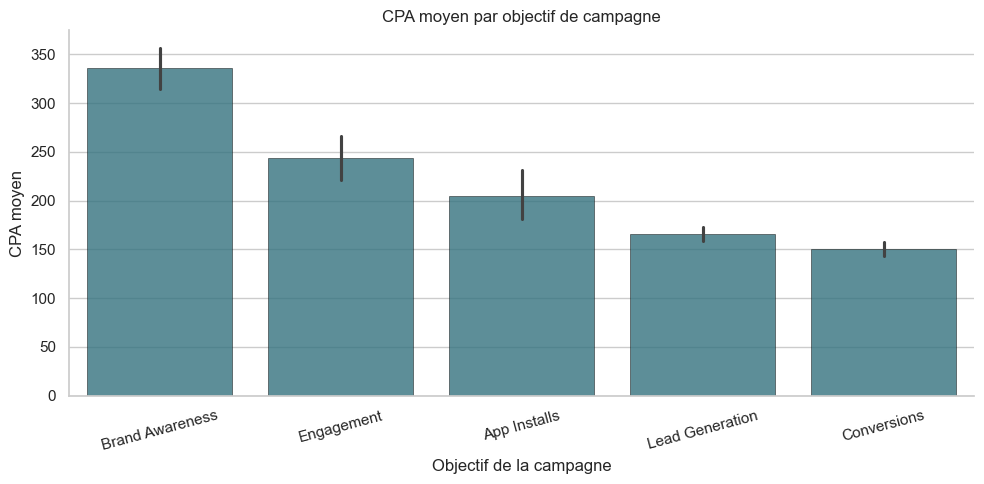

In [219]:
result= campaign.groupby('campaign_objective')['CPA'].mean().sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.set_theme(style='whitegrid')
sns.barplot(
    data=campaign,
    x='campaign_objective',
    y= 'CPA',
    edgecolor='black',
    color=sns.color_palette("crest")[3],
    alpha=0.8,
    linewidth=0.4,
    order=result.index
)
sns.despine()

plt.xticks(rotation=15)
plt.xlabel('Objectif de la campagne')
plt.ylabel('CPA moyen')
plt.title('CPA moyen par objectif de campagne')

plt.tight_layout()
plt.show()

Les campagnes de Lead Generation sont les plus représentées dans le jeu de données. À l’inverse, les campagnes d’App Installs et d’Engagement sont les moins nombreuses.

Les budgets moyens sont relativement homogènes entre les différents objectifs. Les campagnes de Brand Awareness disposent néanmoins du budget moyen le plus élevé, tandis que les campagnes App Installs présentent le budget moyen le plus faible.

Le CTR moyen est très similaire quel que soit l’objectif de campagne. En revanche, les campagnes de Conversion et de Lead Generation affichent les CPA les plus faibles, ce qui est cohérent avec leur objectif de génération de résultats. À l’inverse, les campagnes App Installs présentent un CPA plus élevé, suggérant que l’acquisition d’un nouvel utilisateur est plus coûteuse que la génération d’un lead ou d’une conversion.

Enfin, les campagnes de Conversion et de Lead Generation offrent le meilleur retour sur investissement (ROAS), tandis que les campagnes de Brand Awareness présentent le ROAS le plus faible. Ce résultat reste cohérent avec leur objectif principal, qui est d’accroître la notoriété de la marque plutôt que de générer des revenus à court terme. Les campagnes de Conversion affichent également la plus forte proportion de campagnes rentables, ce qui confirme leur efficacité économique sur ce jeu de données.

### <span style="color:blue"> Analyse 2: Les plateformes publicitaires </span>

***Les performances des plateformes publicitaires varient-elles selon l'objectif de la campagne ?***

2.1 ROAS par plateforme

In [ ]:
pd.pivot_table(
    campaign,
    index='platform',
    columns='campaign_objective',
    values='ROAS',
    aggfunc='mean',
    margins=True
).round(2)

Tik Tok est la plateforme qui obtient les meilleurs resultats sur plusieurs types de campagne. Ces résultats suggèrent qu’il pourrait être pertinent de privilégier TikTok pour les campagnes de Brand Awareness, de Conversion et de Lead Generation. Cette recommandation devrait toutefois être confirmée sur des données réelles et complétée par une analyse des coûts et des volumes.. 
A l'inverse LinkedIn n'est pas une plateforme à privilégier sur ces objectifs, à utiliser avec parsimoni en fonction de la cible.

2.2 CTR par plateforme

In [ ]:
pd.pivot_table(
    campaign,
    index='platform',
    values='CTR',
    columns='campaign_objective',
    aggfunc='mean',
    margins=True
    
).round(3)

In [339]:
# Niveau de CTR

pd.crosstab(
    campaign['platform'],
    campaign['CTR_level'],
    normalize='index'
).round(2)*100

CTR_level,Low,Medium,High
platform,,,
Facebook,24.0,49.0,27.0
Google Ads,27.0,51.0,22.0
Instagram,24.0,50.0,26.0
LinkedIn,26.0,52.0,22.0
TikTok,23.0,49.0,28.0
Twitter,25.0,48.0,28.0


Les différences de CTR entre les plateformes sont très faibles. La majorité des campagnes présentent un niveau de CTR “Medium” et la répartition des niveaux de CTR (Low, Medium et High) est globalement similaire d’une plateforme à l’autre. Le CTR ne semble donc pas constituer un facteur discriminant pour comparer les performances des plateformes sur ce jeu de données.

2.3 CPA par plateforme

In [ ]:
pd.pivot_table(
    campaign,
    index= "platform",
    values= "CPA",
    columns= "campaign_objective",
    aggfunc= "mean",
    margins=True
)

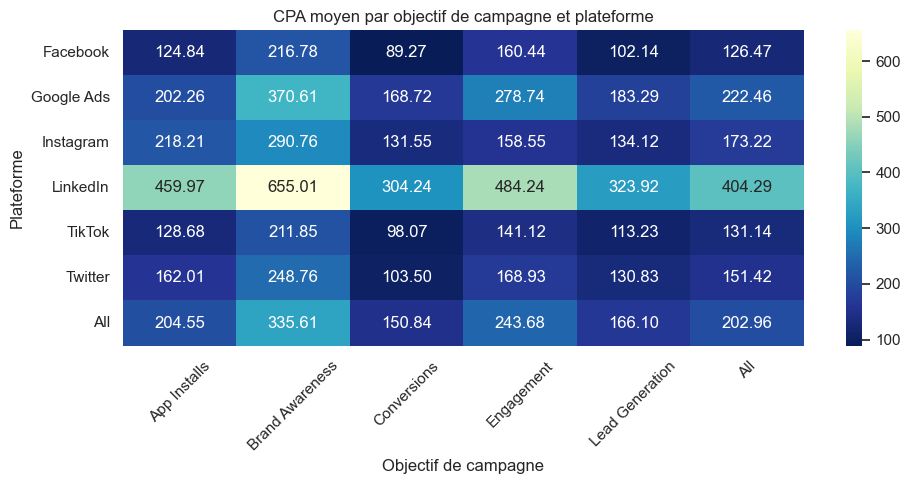

In [257]:
import matplotlib.pyplot as plt
import seaborn as sns 

#CPA 
df_a2 = pd.pivot_table(
    campaign,
    index='platform',
    columns='campaign_objective',
    values='CPA',
    aggfunc='mean',
    margins=True
).round(2)

plt.figure(figsize=(10,5))
sns.heatmap(
   df_a2,
    annot=True,
    cmap='YlGnBu_r',
    fmt='.2f'
    
)
plt.xticks(rotation=45)
plt.xlabel('Objectif de campagne')
plt.ylabel('Plateforme')
plt.title('CPA moyen par objectif de campagne et plateforme')

plt.tight_layout()
plt.show()

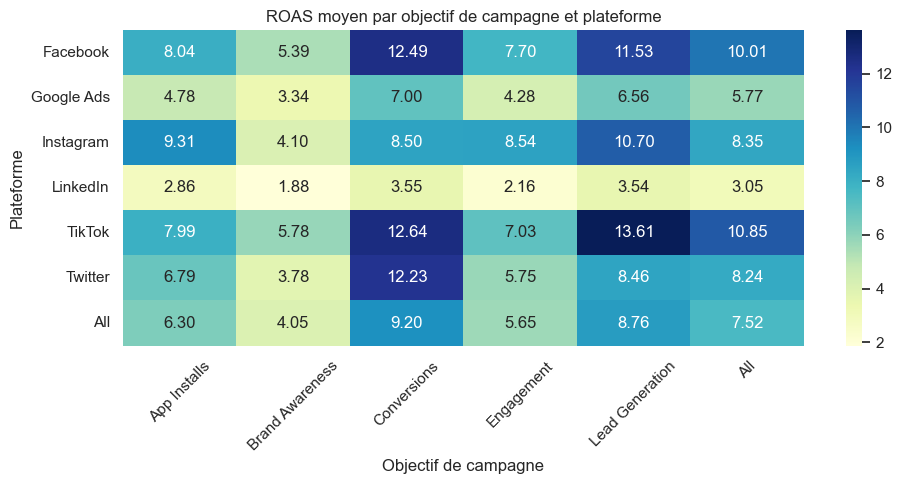

In [258]:
import matplotlib.pyplot as plt
import seaborn as sns 

#CPA 
df_a2 = pd.pivot_table(
    campaign,
    index='platform',
    columns='campaign_objective',
    values='ROAS',
    aggfunc='mean',
    margins=True
).round(2)

plt.figure(figsize=(10,5))
sns.heatmap(
   df_a2,
    annot=True,
    cmap='YlGnBu',
    fmt='.2f'
    
)

plt.xticks(rotation=45)
plt.xlabel('Objectif de campagne')
plt.ylabel('Plateforme')
plt.title('ROAS moyen par objectif de campagne et plateforme')

plt.tight_layout()
plt.show()

Facebook et Tiktok sont les plateformes qui permettent d'obtenir le CPA le moins élevé tout objectif confondu. 
Cela s'observe davantage sur les campagnes avec un objectif de conversions où ces dernières ont un CPA nettement moins élevés que les autres. L'exception se trouve sur les campagne d'engagement où Instagram obtient de meilleurs résultats.


Globalement, TikTok et Facebook présentent les meilleures performances sur plusieurs objectifs de campagne, notamment en termes de ROAS et de CPA. Instagram affiche également de bons résultats, en particulier pour les campagnes d’Engagement, où elle se positionne comme la plateforme la plus performante. Ces résultats suggèrent que le choix de la plateforme doit rester aligné avec l’objectif poursuivi.


*Recommandation* : Adapter le choix de la plateforme à l’objectif marketing. TikTok apparaît comme un bon candidat pour les campagnes orientées performance (Conversion, Lead Generation), tandis qu’Instagram semble particulièrement adapté aux campagnes d’Engagement.

### <span style="color:blue"> Analyse 3: Les creatives </span>

***Le format de la creative influence t-il les performances ?***

In [119]:
campaign.groupby('creative_format').agg({
    'CPA' : 'mean',
    'ROAS': 'mean',
    'CTR' : 'mean',
    'Conversion Rate': 'mean',
}).round(2)

,CPA,ROAS,CTR,Conversion Rate
creative_format,,,,
Carousel,226.07,6.40,0.02,0.03
Image,215.17,7.07,0.02,0.03
Interactive,209.07,6.58,0.03,0.03
Story,237.30,8.30,0.02,0.03
Text,212.12,6.44,0.01,0.03
Video,168.67,9.05,0.03,0.04


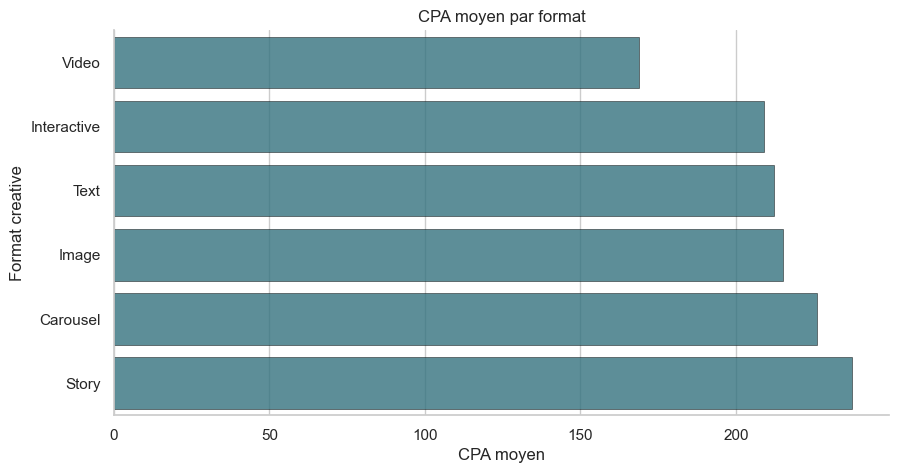

In [270]:
de_a3= pd.pivot_table(
    campaign,
    index='creative_format',
    values='CPA',
    aggfunc='mean'    
).sort_values(by='CPA')

plt.figure(figsize=(10,5))
sns.barplot(
    data= de_a3,
    x= 'CPA',
    y= 'creative_format',
    edgecolor='black',
    color=sns.color_palette("crest")[3],
    alpha=0.8,
    linewidth=0.4,
)
sns.despine()

plt.xlabel('CPA moyen')
plt.ylabel('Format creative')
plt.title('CPA moyen par format')

plt.show()

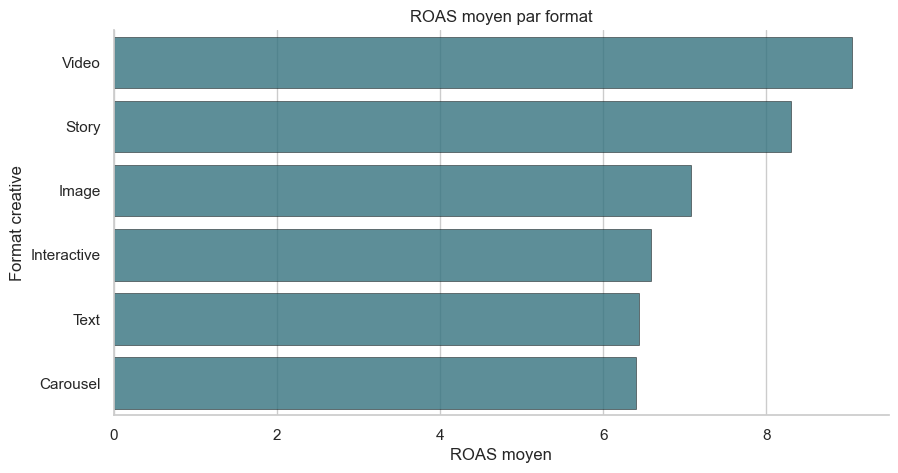

In [273]:
df_a2_bis= pd.pivot_table(
    campaign,
    index='creative_format',
    values='ROAS',
    aggfunc='mean',    
).sort_values(by='ROAS', ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(
    data=df_a2_bis,
    x='ROAS',
    y='creative_format',
    edgecolor='black',
    linewidth=0.4,
    color= sns.color_palette("crest")[3],
    alpha=0.8

)

sns.despine()

plt.title('ROAS moyen par format')
plt.xlabel('ROAS moyen')
plt.ylabel('Format creative')

plt.show()

Les campagnes utilisant le format vidéo présentent globalement les meilleures performances, avec un ROAS élevé et un CPA relativement faible. Les creatives interactives affichent également un CPA compétitif, tandis que le format Story se distingue par un ROAS supérieur à la moyenne. Ces résultats suggèrent que le choix du format peut influencer les performances d’une campagne.

### <span style="color:blue"> Analyse 4: Les emplacements </span> 

***Certains emplacements publicitaires sont-ils plus performants que d’autres ?***

In [122]:
campaign.groupby('ad_placement').agg({
    'CPA' : 'mean',
    'ROAS': 'mean',
    'CTR' : 'mean',
    'Conversion Rate': 'mean',
}).round(2)

,CPA,ROAS,CTR,Conversion Rate
ad_placement,,,,
Display Network,209.67,7.95,0.02,0.04
Feed,195.87,7.25,0.02,0.04
In-Stream Video,201.76,7.57,0.02,0.04
Search,204.43,7.59,0.02,0.04
Sidebar,216.77,8.09,0.02,0.04
Stories,206.79,7.53,0.02,0.04


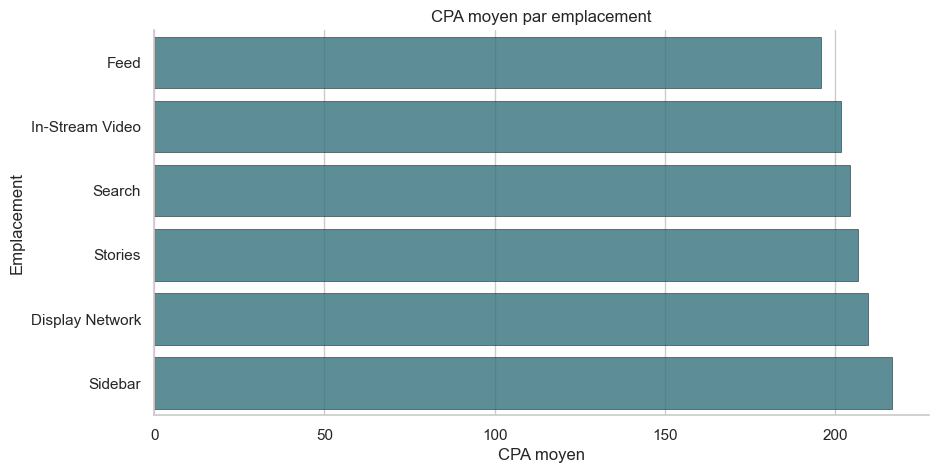

In [280]:
df_a4= pd.pivot_table(
    campaign,
    index='ad_placement',
    values='CPA',
).sort_values(by='CPA')

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_a4,
    x='CPA',
    y= 'ad_placement',
    color= sns.color_palette('crest')[3],
    alpha=0.8,
    edgecolor='black',
    linewidth=0.4,
)

sns.despine()

plt.xlabel('CPA moyen')
plt.ylabel('Emplacement')
plt.title('CPA moyen par emplacement')

plt.show()

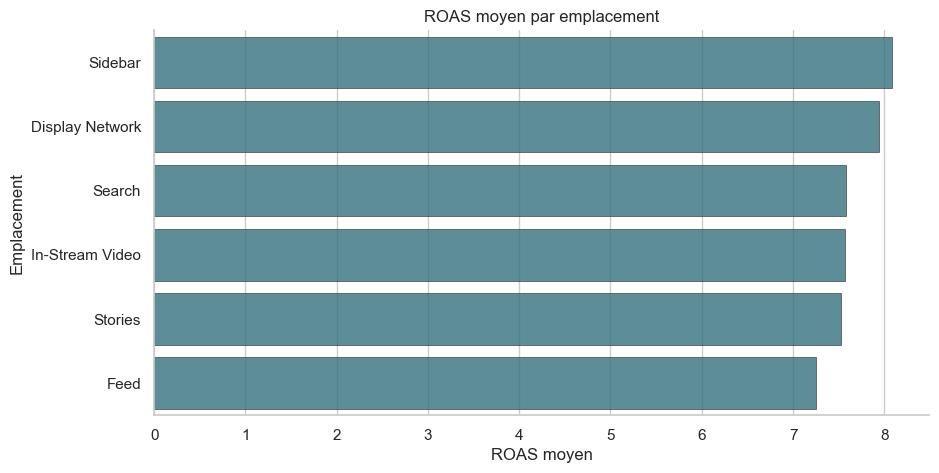

In [282]:
df_a4= pd.pivot_table(
    campaign,
    index='ad_placement',
    values='ROAS',
).sort_values(by='ROAS',ascending=False)

plt.figure(figsize=(10,5))

sns.barplot(
    data=df_a4,
    x='ROAS',
    y= 'ad_placement',
    color= sns.color_palette('crest')[3],
    alpha=0.8,
    edgecolor='black',
    linewidth=0.4,
)

sns.despine()

plt.xlabel('ROAS moyen')
plt.ylabel('Emplacement')
plt.title('ROAS moyen par emplacement')

plt.show()

L’emplacement Feed présente le CPA moyen le plus faible, ce qui en fait l’emplacement le plus performant sur cet indicateur. À l’inverse, l’emplacement Sidebar affiche le ROAS moyen le plus élevé. En revanche, le CTR et le taux de conversion restent très proches d’un emplacement à l’autre et ne permettent pas de mettre en évidence de différences significatives.

### <span style="color:blue"> Analyse 5 — Le device </span> 

***Le device influence-t-il les performances ?***

In [124]:
campaign.groupby('device_type').agg({
    'CPA' : 'mean',
    'ROAS': 'mean',
    'CTR' : 'mean',
    'Conversion Rate': 'mean',
}).round(2)

,CPA,ROAS,CTR,Conversion Rate
device_type,,,,
Desktop,106.16,12.47,0.03,0.06
Mobile,272.07,4.57,0.02,0.02
Tablet,199.19,6.01,0.02,0.03


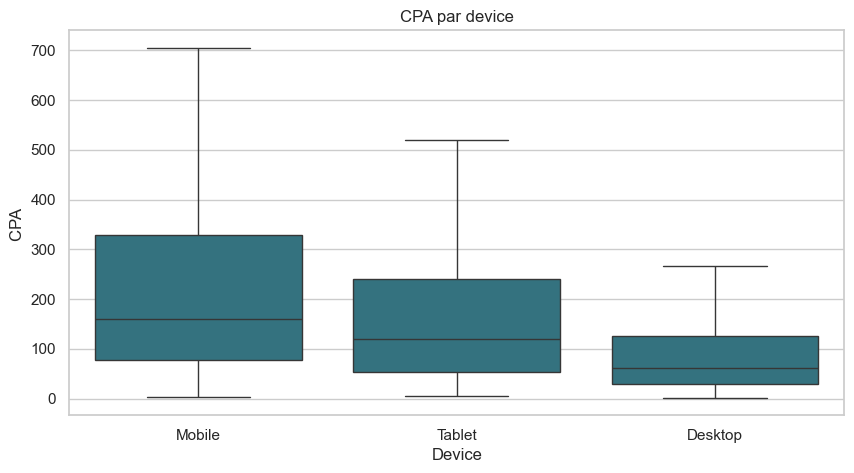

In [294]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=campaign,
    x='device_type',
    y='CPA',
    color= sns.color_palette('crest')[3],
    showfliers=False
)

plt.title('CPA par device')
plt.xlabel('Device')
plt.ylabel('CPA ')

plt.show()

Les campagnes diffusées sur desktop présentent les meilleures performances en termes de CPA, de ROAS, de CTR et de taux de conversion.

Ce résultat peut toutefois surprendre, notamment au regard des performances observées sur TikTok, plateforme majoritairement mobile. Il est donc pertinent de compléter l’analyse par le volume d’impressions généré sur chaque device.

In [138]:
pt = pd.pivot_table(
    campaign,
    index = 'device_type',
    values = 'impressions',
    columns = 'platform',
    aggfunc = 'sum',
    margins= True
)

pt_pct = (pt / pt.loc['All', 'All'] * 100).round(0)

pt_pct

platform,Facebook,Google Ads,Instagram,LinkedIn,TikTok,Twitter,All
device_type,,,,,,,
Desktop,8.0,11.0,3.0,4.0,5.0,3.0,34.0
Mobile,13.0,18.0,5.0,6.0,8.0,6.0,56.0
Tablet,2.0,4.0,1.0,1.0,1.0,1.0,10.0
All,23.0,33.0,9.0,11.0,14.0,9.0,100.0


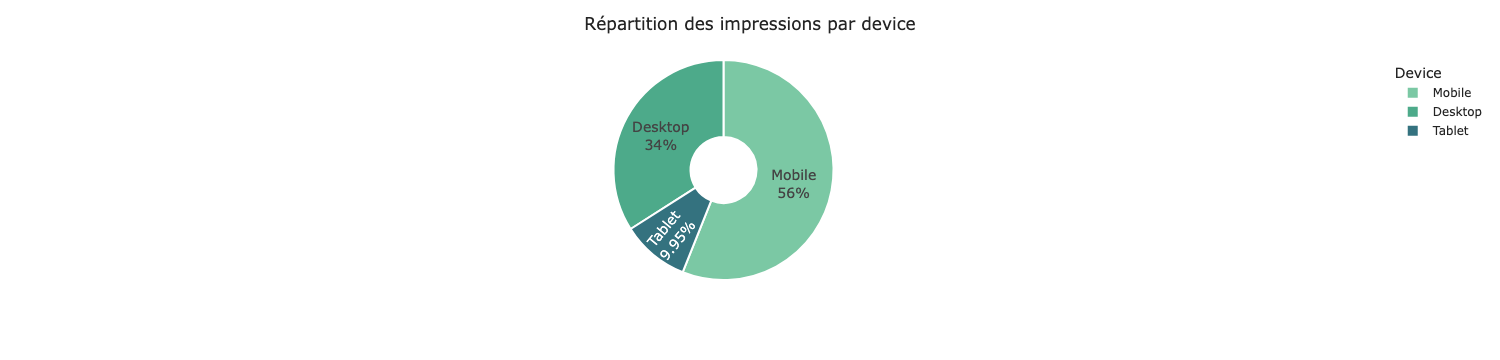

In [299]:
import plotly.express as px

df = campaign.groupby('device_type', as_index=False)['impressions'].sum()

fig = px.pie(
    data_frame=df,
    names='device_type',
    values='impressions',
    hole=0.3,
    color_discrete_sequence=[
        '#7BC8A4',  # vert clair
        '#4DAA8A',  # vert moyen
        '#34727F'   # vert foncé
    ]
)

fig.update_traces(
    textinfo='percent+label',
    textfont_size=14,
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    title='Répartition des impressions par device',
    title_x=0.5,
    legend_title='Device',
    template='simple_white'
)

fig.show()

L’analyse montre que la majorité des impressions est diffusée sur mobile, ce qui est cohérent avec les usages actuels. Ainsi, bien que les performances soient meilleures sur desktop, le volume d’inventaire disponible y est nettement plus faible.

### <span style="color:blue"> Analyse 6 — Le CTA </span> 

***La présence d’un call-to-action améliore-t-elle les performances ?***

In [140]:
campaign.groupby('has_call_to_action').agg({
        'CPA' : 'mean',
    'ROAS': 'mean',
    'CTR' : 'mean',
    'Conversion Rate': 'mean',
}).round(2)

,CPA,ROAS,CTR,Conversion Rate
has_call_to_action,,,,
False,263.76,5.82,0.02,0.03
True,177.39,8.28,0.02,0.04


Text(0.5, 1.0, "Performance du ROAS selon la présence d'un CTA ou non ")

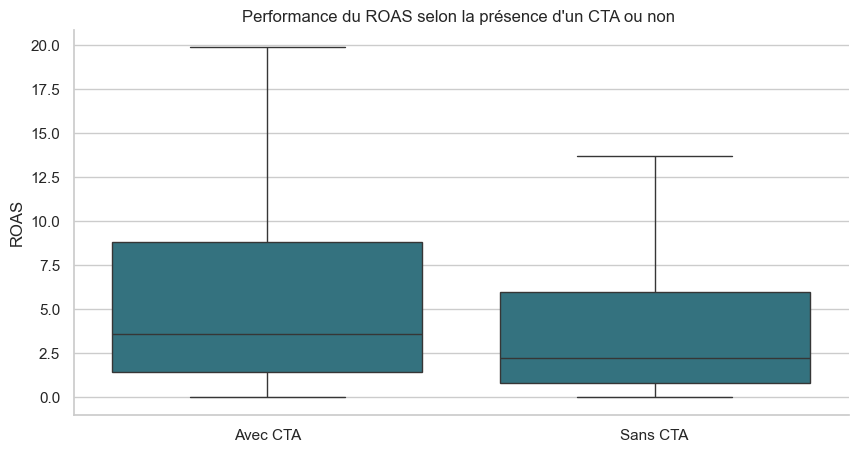

In [315]:
campaign["CTA"] = campaign["has_call_to_action"].map({
    True: "Avec CTA",
    False: "Sans CTA"
})

plt.figure(figsize=(10,5))

sns.boxplot(
    data= campaign,
    x='CTA',
    y='ROAS',
    showfliers=False,
    color=sns.color_palette('crest')[3]
)

sns.despine()

plt.xlabel('')
plt.title('Performance du ROAS selon la présence d\'un CTA ou non ')

Les campagnes intégrant un CTA présentent de meilleures performances sur l’ensemble des KPI étudiés, ce qui suggère qu’un CTA peut contribuer à améliorer l’efficacité des campagnes.

### <span style="color:blue"> Analyse 7 - Retargeting </span> 

**Les campagnes avec du retargeting sont-elles plus performantes ?**

In [153]:
higher_is_better = ['ROAS', 'CTR', 'Conversion Rate']
lower_is_better = ['CPA']

In [151]:
perf = campaign.groupby('retargeting_flag').agg({
        'CPA' : 'mean',
    'ROAS': 'mean',
    'CTR' : 'mean',
    'Conversion Rate': 'mean',
}).round(2)

perf

,CPA,ROAS,CTR,Conversion Rate
retargeting_flag,,,,
False,225.76,6.20,0.02,0.03
True,136.49,11.56,0.03,0.05


Text(0.5, 1.0, 'ROAS selon la mise en place de retargeting')

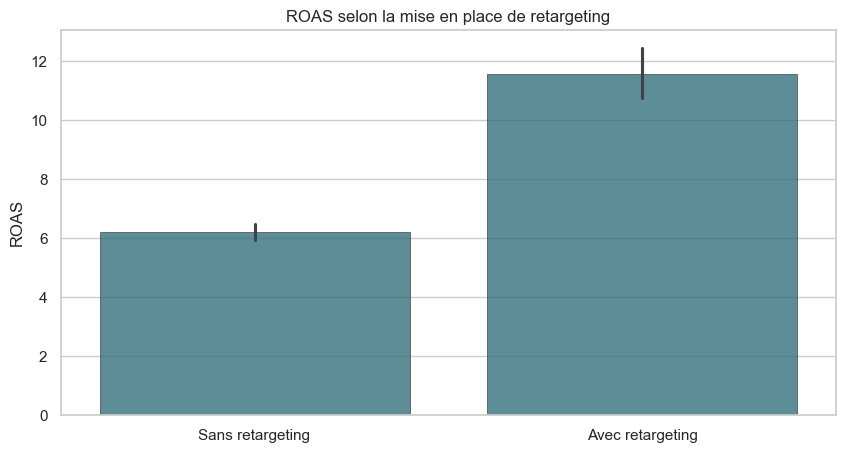

In [317]:
campaign['RTG']= campaign['retargeting_flag'].map({
    True: 'Avec retargeting',
    False: 'Sans retargeting'
})

plt.figure(figsize=(10,5))

sns.barplot(
    data=campaign,
    x='RTG',
    y='ROAS',
    color= sns.color_palette('crest')[3],
    alpha=0.8,
    edgecolor='black',
    linewidth=0.4
)

plt.xlabel('')
plt.title('ROAS selon la mise en place de retargeting')

In [155]:
for metric in perf.columns:

    with_rtg = perf.loc[True, metric]
    without_rtg = perf.loc[False, metric]

    if metric in higher_is_better:
        improvement = (with_rtg / without_rtg - 1) * 100
        print(f"{metric}: +{improvement:.1f}%")

    elif metric in lower_is_better:
        improvement = (1 - with_rtg / without_rtg) * 100
        print(f"{metric}: -{improvement:.1f}%")

CPA: -39.5%
ROAS: +86.5%
CTR: +50.0%
Conversion Rate: +66.7%


On observe que les campagnes intégrant du retargeting sont plus perfomantes sur tous les KPIs. Par exemple les campagnes intégrant du retargeting affichent un ROAS supérieur de 86 % à celles qui n’en utilisent pas.

### <span style="color:blue"> Analyse 8 — Les audiences </span> 

***Quels segments d’audience génèrent les meilleures performances ?***

In [172]:
pd.pivot_table(
    campaign,
    index = 'target_audience_age',
    values = ['CPA','ROAS','CTR','Conversion Rate'],
    aggfunc = 'mean',
    margins= True
).round(2)

,CPA,CTR,Conversion Rate,ROAS
target_audience_age,,,,
18-24,211.16,0.03,0.04,7.36
25-34,205.59,0.03,0.04,7.50
35-44,206.99,0.02,0.04,7.82
45-54,191.46,0.02,0.04,7.88
55-64,186.60,0.02,0.04,7.00
65+,197.68,0.02,0.03,6.35
All,202.96,0.02,0.04,8.00


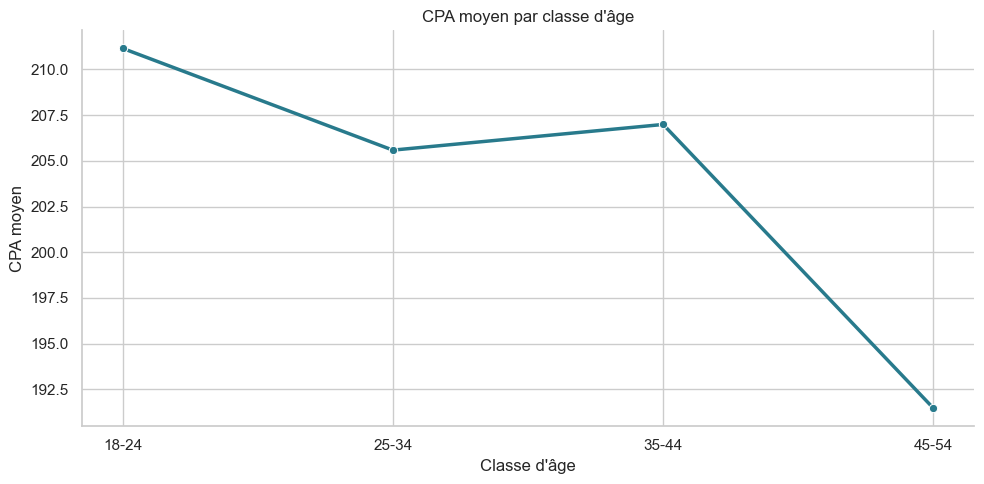

In [329]:
plt.figure(figsize=(10,5))

df = campaign.groupby('target_audience_age', as_index=False)['CPA'].mean()

order = ['18-24','25-34','35-44','45-54','55+']
df['target_audience_age'] = pd.Categorical(
    df['target_audience_age'],
    categories=order,
    ordered=True
)

df = df.sort_values('target_audience_age')

sns.lineplot(
    data=df,
    x='target_audience_age',
    y='CPA',
    marker='o',          # <-- ajoute les points
    linewidth=2.5,       # <-- ligne un peu plus épaisse
    color=sns.color_palette('crest')[3]
)

sns.despine()

plt.xlabel("Classe d'âge")
plt.ylabel("CPA moyen")
plt.title("CPA moyen par classe d'âge")

plt.tight_layout()
plt.show()

In [170]:
pd.pivot_table(
    campaign,
    index = 'target_audience_gender',
    values = ['CPA','ROAS','CTR','Conversion Rate'],
    aggfunc = 'mean',
).round(2)

,CPA,CTR,Conversion Rate,ROAS
target_audience_gender,,,,
All,206.70,0.02,0.04,7.67
Female,197.31,0.02,0.04,7.54
Male,205.45,0.02,0.04,7.38


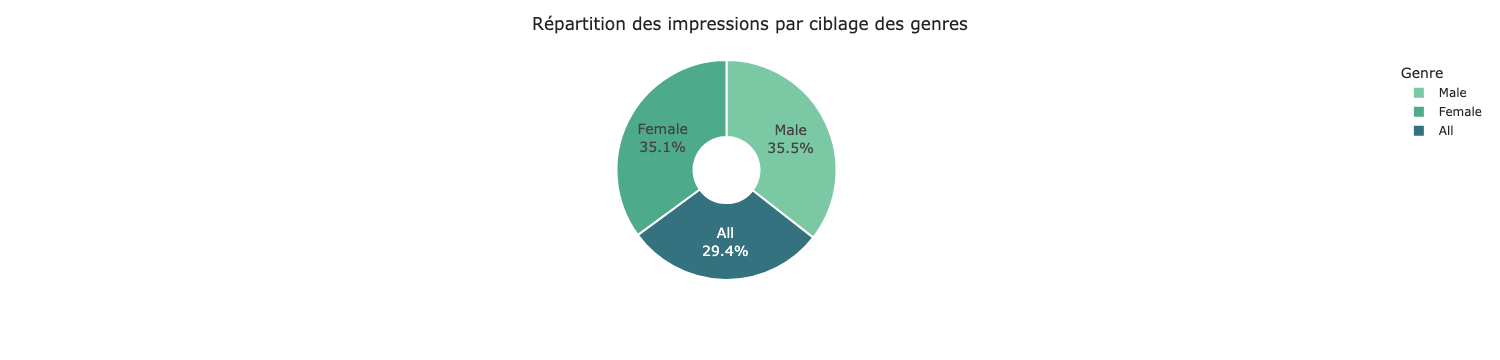

In [325]:
import plotly.express as px

df = campaign.groupby('target_audience_gender', as_index=False)['conversions'].sum()

fig = px.pie(
    data_frame=df,
    names='target_audience_gender',
    values='conversions',
    hole=0.3,
    color_discrete_sequence=[
        '#7BC8A4',  # vert clair
        '#4DAA8A',  # vert moyen
        '#34727F'   # vert foncé
    ]
)

fig.update_traces(
    textinfo='percent+label',
    textfont_size=14,
    marker=dict(line=dict(color='white', width=2))
)

fig.update_layout(
    title='Répartition des impressions par ciblage des genres',
    title_x=0.5,
    legend_title='Genre',
    template='simple_white'
)

fig.show()

In [171]:
pd.pivot_table(
    campaign,
    index = 'audience_interest_category',
    values = ['CPA','ROAS','CTR','Conversion Rate'],
    aggfunc = 'mean',
    margins=True
).round(2)

,CPA,CTR,Conversion Rate,ROAS
audience_interest_category,,,,
Business Professionals,200.70,0.02,0.04,7.99
Gamers,199.57,0.02,0.04,7.51
Health & Fitness,208.11,0.02,0.03,6.63
Shoppers,205.17,0.02,0.04,7.28
Students,199.11,0.02,0.04,7.89
Tech Enthusiasts,206.76,0.02,0.03,7.28
All,202.96,0.02,0.04,8.00


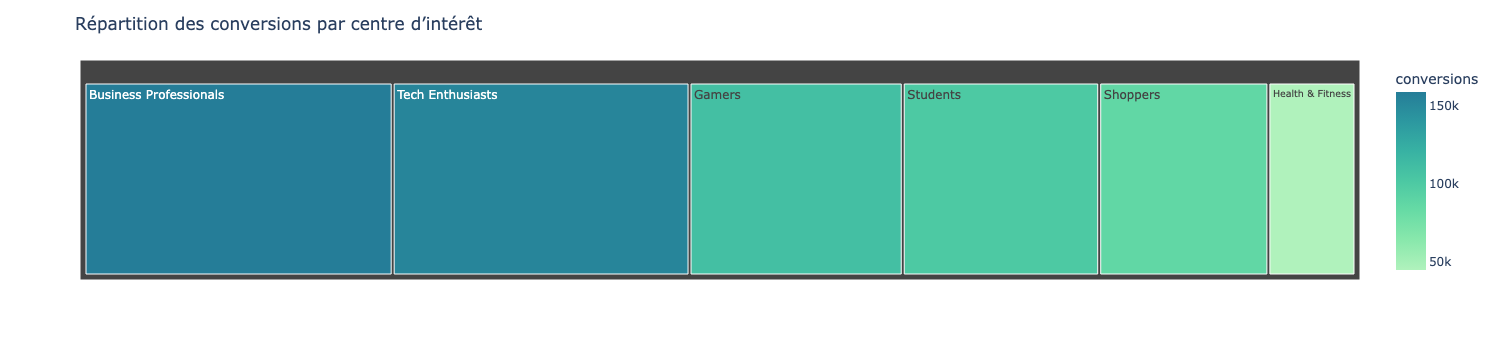

In [328]:
df = campaign.groupby(
    'audience_interest_category',
    as_index=False
)['conversions'].sum()

fig = px.treemap(
    df,
    path=['audience_interest_category'],
    values='conversions',
    color='conversions',
    color_continuous_scale='Tealgrn'
)

fig.update_layout(
    title='Répartition des conversions par centre d’intérêt'
)

fig.show()

Les performances varient peu selon les segments d’audience. Aucune tranche d’âge, genre ou centre d’intérêt ne se démarque nettement sur ce jeu de données.

### <span style="color:blue"> Analyse 9 — Le budget </span> 

***Les campagnes disposant d’un budget plus important sont-elles plus performantes ?***

In [176]:
campaign.groupby('budget_tier').agg({
     'CPA' : 'mean',
    'ROAS': 'mean',
    'CTR' : 'mean',
    'Conversion Rate': 'mean',
}).round(2)


,CPA,ROAS,CTR,Conversion Rate
budget_tier,,,,
High,215.57,7.55,0.02,0.04
Low,192.82,7.16,0.02,0.04
Medium,204.43,7.80,0.02,0.04


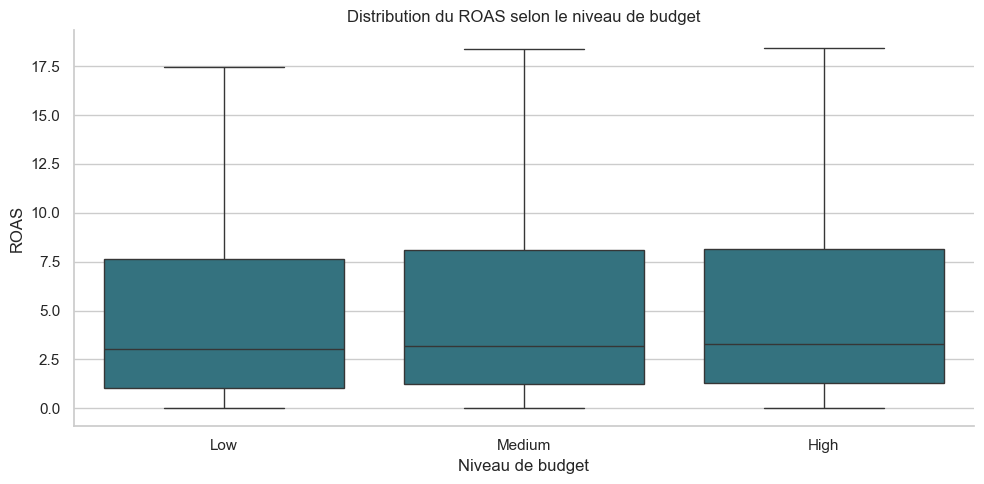

In [330]:
plt.figure(figsize=(10,5))

sns.boxplot(
    data=campaign,
    x='budget_tier',
    y='ROAS',
    order=['Low', 'Medium', 'High'],
    showfliers=False,
    color=sns.color_palette('crest')[3]
)

sns.despine()

plt.xlabel("Niveau de budget")
plt.ylabel("ROAS")
plt.title("Distribution du ROAS selon le niveau de budget")

plt.tight_layout()
plt.show()

Les campagnes disposant des budgets les plus faibles présentent les meilleurs KPI de performance. Cette observation mériterait d’être approfondie afin de déterminer si elle s’explique par un ciblage plus précis, une meilleure qualité des campagnes ou un effet propre au jeu de données.

## Phase 5 - Conclusion 

### <span style="color:blue"> 5.1 Analyse </span>

* Les campagnes de Conversion et Lead Generation présentent les meilleurs ROAS.
* TikTok et Facebook sont les plateformes les plus performantes.
* Les formats vidéo obtiennent les meilleurs résultats.
* Les campagnes intégrant un CTA et du retargeting affichent de meilleures performances.
* Les performances varient peu selon les segments d’audience.

### <span style="color:blue"> 5.2 Recommandations Business </span>

* Renforcer les investissements sur TikTok pour les campagnes de conversion.
* Généraliser l’utilisation d’un CTA lorsque cela est pertinent.
* Développer davantage de campagnes de retargeting.
* Prioriser les formats vidéo.
* Tester des allocations budgétaires plus faibles sur certains objectifs afin de confirmer les résultats observés.